## CT Normal vs Abnormal - MVP Pipeline

Outline:
1. Configure paths and environment
2. Scan datasets (DICOM/NIfTI) and build a study manifest
3. Visualize random studies/slices
4. Dataset + transforms (windowing, resize)
5. Train baseline (2D ResNet18) on slices
6. Evaluate with study-level aggregation
7. Inference demo

Run each section sequentially. Keep it simple and fast for laptop execution.


In [1]:
# 1) Config (with registry-driven labels)
import os, sys, pathlib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# FIXED EXPORT CELL: Use this instead of the broken cell above
import SimpleITK as sitk
import numpy as np
from pathlib import Path
import imageio.v2 as iio
import zipfile
import tempfile
import pydicom
from PIL import Image
import SimpleITK as sitk


# Root where you download datasets
DATA_ROOT = "/Users/stepanguranov/Documents/hackathon_2025/Датасет"
# Where to save generated artifacts (slices, manifests, models)
OUT_ROOT = "/Users/stepanguranov/Documents/hackathon_2025/outputs"
pathlib.Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

# Registry path (example: MosMedData registry with study UID + pathology 0/1)
REGISTRY_XLSX = os.path.join(DATA_ROOT, "MosMedData-CT-COVID19-type I-v 3", "dataset_registry.xlsx")

# Base directory containing actual DICOM series folders for this registry
REGISTRY_CT_DIR = os.path.join(DATA_ROOT, "MosMedData-CT-COVID19-type I-v 3", "CT")

print("Registry exists:", os.path.isfile(REGISTRY_XLSX))
print("CT dir exists:", os.path.isdir(REGISTRY_CT_DIR))


Registry exists: True
CT dir exists: True


In [2]:

# Load registry (study_instance_anon as UID, pathology in {0,1})
reg = pd.read_excel(REGISTRY_XLSX)
reg = reg.rename(columns={"study_instance_anon": "study_uid", "pathology": "label"})
reg['label'] = reg['label'].astype(int)
print("Registry rows:", len(reg), "unique UIDs:", reg['study_uid'].nunique())

# MosMed layout here is CT/<StudyUID>/(many nested folders)/DICOM files
ct_root = Path(REGISTRY_CT_DIR)
uid_to_root = {d.name: str(d) for d in ct_root.iterdir() if d.is_dir()}
reg['study_root'] = reg['study_uid'].map(uid_to_root)
reg_avail = reg.dropna(subset=['study_root']).reset_index(drop=True)
print("Available study roots:", len(reg_avail))


def collect_series_under(study_root: str):
    found = []
    for dirpath, dirnames, filenames in os.walk(study_root):
        try:
            r = sitk.ImageSeriesReader()
            sids = r.GetGDCMSeriesIDs(dirpath) or []
        except Exception:
            sids = []
        for sid in sids:
            files = r.GetGDCMSeriesFileNames(dirpath, sid)
            if files:
                found.append((sid, files))
    return found

# For each study, pick the largest series by number of files
studies = []  # (series_uid, label, files)
for _, row in reg_avail.iterrows():
    uid = row['study_uid']
    label = int(row['label'])
    study_root = row['study_root']
    all_series = collect_series_under(study_root)
    if not all_series:
        continue
    sid, files = max(all_series, key=lambda x: len(x[1]))
    studies.append((sid, label, files))

print("Found series:", len(studies))
print("Label balance:", sum(1 for s in studies if s[1]==0), "normal /", sum(1 for s in studies if s[1]==1), "abnormal")

series_manifest = pd.DataFrame([
    {"series_uid": sid, "label": label, "num_slices": len(files)} for sid, label, files in studies
])
series_manifest_path = os.path.join(OUT_ROOT, "series_manifest.csv")
series_manifest.to_csv(series_manifest_path, index=False)
series_manifest.head()[:3]


Registry rows: 197 unique UIDs: 197
Available study roots: 194


GDCMSeriesFileNames (0x10e919e70): No Series were found

GDCMSeriesFileNames (0x11f1551d0): No Series were found

GDCMSeriesFileNames (0x11e4d6a00): No Series were found

GDCMSeriesFileNames (0x11f154c80): No Series were found

GDCMSeriesFileNames (0x10c6c54a0): No Series were found

GDCMSeriesFileNames (0x11fc049b0): No Series were found

GDCMSeriesFileNames (0x11f153e30): No Series were found

GDCMSeriesFileNames (0x11e4d6960): No Series were found

GDCMSeriesFileNames (0x11fbe0390): No Series were found

GDCMSeriesFileNames (0x10c6c5840): No Series were found

GDCMSeriesFileNames (0x11bbffaa0): No Series were found

GDCMSeriesFileNames (0x10c6c6930): No Series were found

GDCMSeriesFileNames (0x11f153e30): No Series were found

GDCMSeriesFileNames (0x11bcff8d0): No Series were found

GDCMSeriesFileNames (0x10c6c56b0): No Series were found

GDCMSeriesFileNames (0x11bbff570): No Series were found

GDCMSeriesFileNames (0x11bcff8d0): No Series were found

GDCMSeriesFileNames (0x11bbff77

Found series: 194
Label balance: 96 normal / 98 abnormal


,series_uid,label,num_slices
0,1.2.643.5.1.13.13.12.2.77.8252.120601130802141...,1,413
1,1.2.643.5.1.13.13.12.2.77.8252.040515121108090...,0,1201
2,1.2.643.5.1.13.13.12.2.77.8252.000513021507151...,1,1201


In [3]:
series_manifest

,series_uid,label,num_slices
0,1.2.643.5.1.13.13.12.2.77.8252.120601130802141...,1,413
1,1.2.643.5.1.13.13.12.2.77.8252.040515121108090...,0,1201
2,1.2.643.5.1.13.13.12.2.77.8252.000513021507151...,1,1201
3,1.2.643.5.1.13.13.12.2.77.8252.091505030606040...,1,451
4,1.2.643.5.1.13.13.12.2.77.8252.011008070309101...,1,876
...,...,...,...
92,1.2.643.5.1.13.13.12.2.77.8252.001110121015000...,0,826
93,1.2.643.5.1.13.13.12.2.77.8252.011006040315131...,1,444
94,1.2.643.5.1.13.13.12.2.77.8252.030604100308130...,0,382
95,1.2.643.5.1.13.13.12.2.77.8252.061011121008071...,1,382


In [3]:
SLICE_OUT = os.path.join(OUT_ROOT, "slices")
Path(SLICE_OUT).mkdir(parents=True, exist_ok=True)

def to_3d(image: sitk.Image, t_index: int = 0) -> sitk.Image:
    """Collapse 4D (X,Y,Z,T) to 3D by selecting frame T=t_index"""
    if image.GetDimension() == 4:
        size = list(image.GetSize())
        index = [0, 0, 0, 0]
        index[3] = t_index
        size[3] = 0  # collapse last dimension
        extractor = sitk.ExtractImageFilter()
        extractor.SetSize(size)
        extractor.SetIndex(index)
        image = extractor.Execute(image)
    return image

def window_lung(image: sitk.Image, center=-600.0, width=1500.0):
    # Cast to float32 to avoid 16-bit int issues with IntensityWindowing
    image = sitk.Cast(image, sitk.sitkFloat32)
    min_v, max_v = center - width/2, center + width/2
    win = sitk.IntensityWindowing(image, float(min_v), float(max_v), 0.0, 255.0)
    return sitk.Cast(win, sitk.sitkUInt8)

MAX_SLICES = 64
rows = []
for sid, label, files in studies:
    r = sitk.ImageSeriesReader()
    r.SetFileNames(files)
    try:
        img = r.Execute()
    except Exception as e:
        print(f"Failed to read {sid}: {e}")
        continue
    
    # Fix 4D issue: collapse to 3D first
    img = to_3d(img)
    if img.GetDimension() != 3:
        print(f"Skipping {sid}: not 3D after collapse")
        continue
    
    try:
        img8 = window_lung(img)
    except Exception as e:
        print(f"Failed to window {sid}: {e}")
        continue
    
    vol = sitk.GetArrayFromImage(img8)  # (Z, Y, X)
    if vol.ndim != 3 or vol.shape[0] < 2:
        continue
    
    z = vol.shape[0]
    idxs = np.arange(z) if z <= MAX_SLICES else np.linspace(0, z-1, MAX_SLICES, dtype=int)
    
    for i in idxs:
        arr = vol[i]
        out_path = os.path.join(SLICE_OUT, f"{sid.replace('.', '_')}_z{i:03d}.png")
        iio.imwrite(out_path, arr)
        rows.append({"filepath": out_path, "label": int(label), "study_id": sid.replace('.', '_')})

slice_manifest = pd.DataFrame(rows)
slice_manifest_path = os.path.join(OUT_ROOT, "slice_manifest.csv")
slice_manifest.to_csv(slice_manifest_path, index=False)
print("Slices saved (FIXED):", len(slice_manifest))
slice_manifest.head()[:3]


ImageSeriesReader (0x1298ffe10): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000100243

ImageSeriesReader (0x11e4c32e0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.001

ImageSeriesReader (0x12a695b60): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x11e4c32e0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x11e4c32e0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x11ed12710): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x10c698fc0): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.001

ImageSeriesReader (0x128dffe80): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.0001

ImageSeriesReader (0x12c455550): Non uniform sampling or missing slices detected,  maximum no

Slices saved (FIXED): 12416


,filepath,label,study_id
0,/Users/stepanguranov/Documents/hackathon_2025/...,1,1_2_643_5_1_13_13_12_2_77_8252_120601130802141...
1,/Users/stepanguranov/Documents/hackathon_2025/...,1,1_2_643_5_1_13_13_12_2_77_8252_120601130802141...
2,/Users/stepanguranov/Documents/hackathon_2025/...,1,1_2_643_5_1_13_13_12_2_77_8252_120601130802141...


In [ ]:
# Setup for hyperparameter search (imports, transforms, dataset)
import os
import pathlib
import pandas as pd
import numpy as np
from PIL import Image


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score, accuracy_score

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)

# Transforms (define if missing)
if 'train_transform_light' not in globals():
    train_transform_light = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(5),
        transforms.RandomHorizontalFlip(0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

if 'val_transform' not in globals():
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

# Paths
if 'OUT_ROOT' not in globals():
    OUT_ROOT = '/Users/stepanguranov/Documents/hackathon_2025/outputs'
if 'slice_manifest_path' not in globals():
    slice_manifest_path = os.path.join(OUT_ROOT, 'slice_manifest.csv')

if not pathlib.Path(slice_manifest_path).exists():
    print('WARNING: slice_manifest.csv not found at', slice_manifest_path)

# Dataset (define if missing)
if 'SliceDatasetImproved' not in globals():
    class SliceDatasetImproved(Dataset):
        def __init__(self, manifest_csv, split_ratio=0.8, train=True, seed=42):
            df = pd.read_csv(manifest_csv)
            sids = df['study_id'].unique()
            rng = np.random.default_rng(seed)
            rng.shuffle(sids)
            cut = int(len(sids) * split_ratio)
            keep = set(sids[:cut] if train else sids[cut:])
            df = df[df['study_id'].isin(keep)].reset_index(drop=True)
            self.filepaths = df['filepath'].tolist()
            self.labels = df['label'].astype(int).tolist()
            self.study_ids = df['study_id'].tolist()
            self.transform = train_transform_light if train else val_transform

        def __len__(self):
            return len(self.filepaths)

        def __getitem__(self, idx):
            img = Image.open(self.filepaths[idx]).convert('L')
            img = Image.merge('RGB', (img, img, img))
            x = self.transform(img)
            y = torch.tensor(self.labels[idx], dtype=torch.float32)
            return x, y, self.study_ids[idx]



Using device: mps


In [7]:
import json
print("=== HYPERPARAMETER SEARCH ===")

# Search space for 200 studies
param_combinations = [
    {'lr': 5e-5, 'dropout': 0.3, 'weight_decay': 1e-3, 'batch_size': 16},
    # {'lr': 1e-4, 'dropout': 0.5, 'weight_decay': 1e-2, 'batch_size': 16},
    # {'lr': 2e-4, 'dropout': 0.7, 'weight_decay': 1e-3, 'batch_size': 8},
    # {'lr': 1e-4, 'dropout': 0.3, 'weight_decay': 1e-4, 'batch_size': 32},
    # {'lr': 5e-5, 'dropout': 0.5, 'weight_decay': 1e-2, 'batch_size': 8},
]

results = []

for trial, params in enumerate(param_combinations):
    print(f"\nTrial {trial+1}/{len(param_combinations)}: {params}")
    
    # Create model
    model_hp = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model_hp.fc = nn.Sequential(
        nn.Dropout(params['dropout']),
        nn.Linear(model_hp.fc.in_features, 1)
    )
    model_hp = model_hp.to(device)
    
    # Data loaders
    train_ds_hp = SliceDatasetImproved(slice_manifest_path, train=True)
    val_ds_hp = SliceDatasetImproved(slice_manifest_path, train=False)
    train_loader_hp = DataLoader(train_ds_hp, batch_size=params['batch_size'], shuffle=True, num_workers=0)
    val_loader_hp = DataLoader(val_ds_hp, batch_size=params['batch_size'], shuffle=False, num_workers=0)
    
    # Optimizer
    criterion_hp = nn.BCEWithLogitsLoss()
    optimizer_hp = torch.optim.Adam(model_hp.parameters(), 
                                    lr=params['lr'], 
                                    weight_decay=params['weight_decay'])
    
    # Training (up to 10 epochs with early stopping)
    best_auc = -1
    epochs_done = 0
    patience = 0
    
    for epoch in range(1, 5):
        print(f"Epoch {epoch} of 4")
        # Train
        model_hp.train()
        train_losses = []
        for x, y, _ in train_loader_hp:
            x, y = x.to(device), y.to(device).unsqueeze(1)
            optimizer_hp.zero_grad()
            loss = criterion_hp(model_hp(x), y)
            loss.backward()
            optimizer_hp.step()
            train_losses.append(loss.item())
        
        # Validate (study-level)
        model_hp.eval()
        slice_probs, slice_labels, slice_studies = [], [], []
        with torch.no_grad():
            for x, y, study_ids in val_loader_hp:
                probs = torch.sigmoid(model_hp(x.to(device))).squeeze(1).cpu().numpy()
                slice_probs.extend(probs)
                slice_labels.extend(y.numpy())
                slice_studies.extend(study_ids)
        
        # Aggregate by study
        study_data = {}
        for p, l, s in zip(slice_probs, slice_labels, slice_studies):
            if s not in study_data:
                study_data[s] = {'probs': [], 'label': l}
            study_data[s]['probs'].append(p)
        
        study_probs = [np.mean(d['probs']) for d in study_data.values()]
        study_labels = [d['label'] for d in study_data.values()]
        auc = roc_auc_score(study_labels, study_probs) if len(set(study_labels)) > 1 else 0.0
        
        epochs_done = epoch
        if auc > best_auc:
            best_auc = auc
            patience = 0
        else:
            patience += 1
            if patience >= 3:
                break
    
    results.append({
        'trial': trial + 1,
        'params': params,
        'best_auc': best_auc,
        'epochs': epochs_done,
        'train_loss': np.mean(train_losses)
    })
    print(f"Result: AUC={best_auc:.4f} in {epochs_done} epochs")

# Best result
best = max(results, key=lambda x: x['best_auc'])
print(f"\n🏆 BEST: AUC={best['best_auc']:.4f}")
print(f"Params: {best['params']}")

# Save results
with open(os.path.join(OUT_ROOT, 'hp_search.json'), 'w') as f:
    json.dump(results, f, indent=2)

BEST_PARAMS = best['params']
print(f"✅ Best params: {BEST_PARAMS}")


=== HYPERPARAMETER SEARCH ===

Trial 1/1: {'lr': 5e-05, 'dropout': 0.3, 'weight_decay': 0.001, 'batch_size': 16}
Epoch 1 of 4
Epoch 2 of 4
Epoch 3 of 4
Epoch 4 of 4
Result: AUC=0.5132 in 4 epochs

🏆 BEST: AUC=0.5132
Params: {'lr': 5e-05, 'dropout': 0.3, 'weight_decay': 0.001, 'batch_size': 16}
✅ Best params: {'lr': 5e-05, 'dropout': 0.3, 'weight_decay': 0.001, 'batch_size': 16}


=== FINAL TRAINING WITH BEST HYPERPARAMETERS ===
Training with best params: {'lr': 5e-05, 'dropout': 0.3, 'weight_decay': 0.001, 'batch_size': 16}
Max epochs: 5, Early stopping patience: 5
Epoch  1: train_loss=0.4151, val_loss=2.0159, study_auc=0.4316, lr=5.00e-05
  🎯 New best model saved! AUC: 0.4316
Epoch  2: train_loss=0.1698, val_loss=1.8067, study_auc=0.4711, lr=5.00e-05
  🎯 New best model saved! AUC: 0.4711
Epoch  3: train_loss=0.1027, val_loss=1.8064, study_auc=0.5316, lr=5.00e-05
  🎯 New best model saved! AUC: 0.5316
Epoch  4: train_loss=0.0784, val_loss=2.5624, study_auc=0.4447, lr=5.00e-05
Epoch  5: train_loss=0.0429, val_loss=2.8562, study_auc=0.4684, lr=5.00e-05

🏁 Training completed!
Best study AUC: 0.5316
Model saved: final_model_200ct.pt


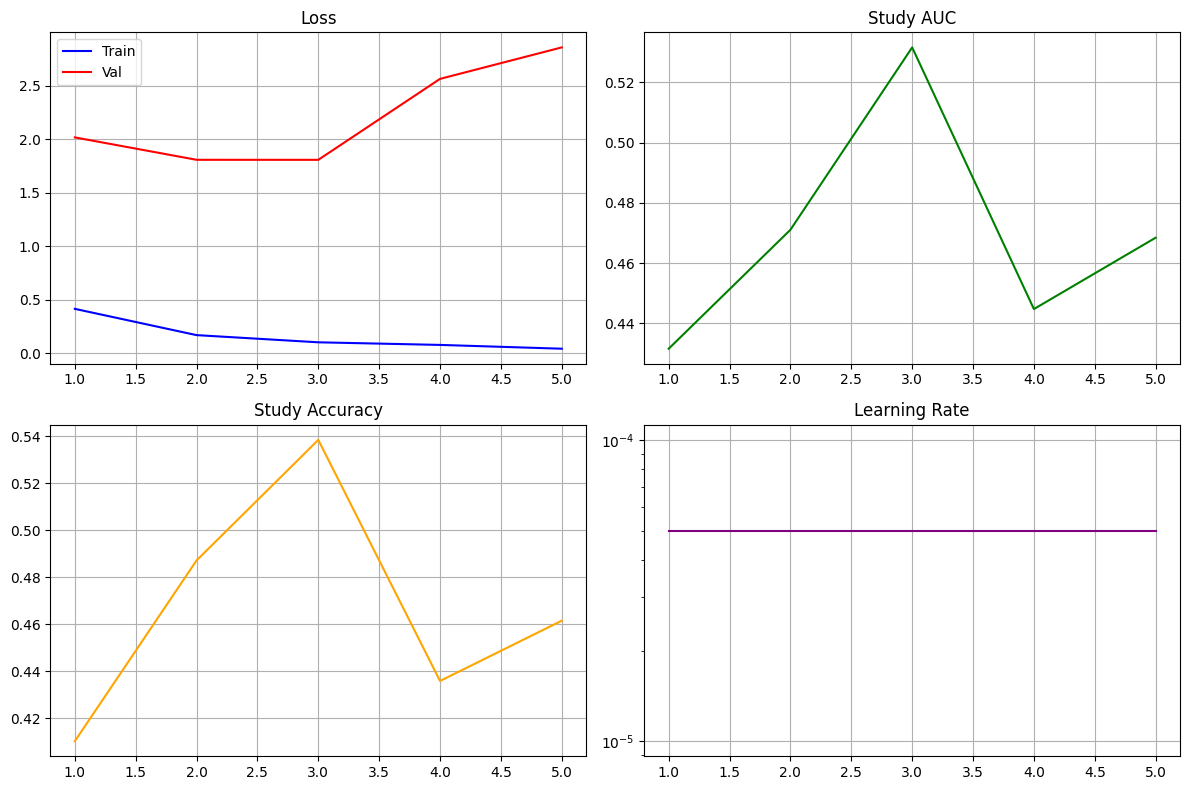

In [10]:
# FINAL TRAINING with best hyperparameters + more epochs
print("=== FINAL TRAINING WITH BEST HYPERPARAMETERS ===")

# Create final model with best params
model_final = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_final.fc = nn.Sequential(
    nn.Dropout(BEST_PARAMS['dropout']),
    nn.Linear(model_final.fc.in_features, 1)
)
model_final = model_final.to(device)

# Final data loaders with best batch size
train_ds_final = SliceDatasetImproved(slice_manifest_path, train=True)
val_ds_final = SliceDatasetImproved(slice_manifest_path, train=False)
train_loader_final = DataLoader(train_ds_final, batch_size=BEST_PARAMS['batch_size'], shuffle=True, num_workers=0)
val_loader_final = DataLoader(val_ds_final, batch_size=BEST_PARAMS['batch_size'], shuffle=False, num_workers=0)

# Optimizer with best params
criterion_final = nn.BCEWithLogitsLoss()
optimizer_final = torch.optim.Adam(model_final.parameters(), 
                                   lr=BEST_PARAMS['lr'], 
                                   weight_decay=BEST_PARAMS['weight_decay'])

# Learning rate scheduler (reduce on plateau)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='min', factor=0.5, patience=3
)

# Extended training with best params
EPOCHS = 5  # More epochs for 200 studies
best_val_auc = -1
patience = 0
patience_limit = 5  # More patience for larger dataset

print(f"Training with best params: {BEST_PARAMS}")
print(f"Max epochs: {EPOCHS}, Early stopping patience: {patience_limit}")

history = {'train_loss': [], 'val_loss': [], 'study_auc': [], 'study_acc': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    # Training
    model_final.train()
    train_losses = []
    for x, y, _ in train_loader_final:
        x, y = x.to(device), y.to(device).unsqueeze(1)
        optimizer_final.zero_grad()
        loss = criterion_final(model_final(x), y)
        loss.backward()
        optimizer_final.step()
        train_losses.append(loss.item())
    
    # Validation with study aggregation
    model_final.eval()
    val_losses = []
    slice_probs, slice_labels, slice_studies = [], [], []
    
    with torch.no_grad():
        for x, y, study_ids in val_loader_final:
            x, y = x.to(device), y.to(device).unsqueeze(1)
            logits = model_final(x)
            val_loss = criterion_final(logits, y)
            val_losses.append(val_loss.item())
            
            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            slice_probs.extend(probs)
            slice_labels.extend(y.squeeze(1).cpu().numpy())
            slice_studies.extend(study_ids)
    
    # Study-level metrics
    study_data = {}
    for p, l, s in zip(slice_probs, slice_labels, slice_studies):
        if s not in study_data:
            study_data[s] = {'probs': [], 'label': l}
        study_data[s]['probs'].append(p)
    
    study_probs = [np.mean(d['probs']) for d in study_data.values()]
    study_labels = [d['label'] for d in study_data.values()]
    
    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)
    study_auc = roc_auc_score(study_labels, study_probs) if len(set(study_labels)) > 1 else 0.0
    study_acc = accuracy_score(study_labels, (np.array(study_probs) >= 0.5).astype(int))
    
    # Update scheduler
    scheduler.step(val_loss)
    current_lr = optimizer_final.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['study_auc'].append(study_auc)
    history['study_acc'].append(study_acc)
    history['lr'].append(current_lr)
    
    print(f"Epoch {epoch:2d}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, study_auc={study_auc:.4f}, lr={current_lr:.2e}")
    
    # Early stopping and model saving
    if study_auc > best_val_auc:
        best_val_auc = study_auc
        patience = 0
        # Save best model
        torch.save({
            'model_state_dict': model_final.state_dict(),
            'params': BEST_PARAMS,
            'epoch': epoch,
            'study_auc': study_auc,
            'study_acc': study_acc,
            'history': history
        }, os.path.join(OUT_ROOT, 'final_model_200ct.pt'))
        print(f"  🎯 New best model saved! AUC: {study_auc:.4f}")
    else:
        patience += 1
        if patience >= patience_limit:
            print(f"  ⏹ Early stopping at epoch {epoch}")
            break

print(f"\n🏁 Training completed!")
print(f"Best study AUC: {best_val_auc:.4f}")
print(f"Model saved: final_model_200ct.pt")

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0,0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0,0].plot(epochs_range, history['val_loss'], 'r-', label='Val')
axes[0,0].set_title('Loss')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(epochs_range, history['study_auc'], 'g-')
axes[0,1].set_title('Study AUC')
axes[0,1].grid(True)

axes[1,0].plot(epochs_range, history['study_acc'], 'orange')
axes[1,0].set_title('Study Accuracy')
axes[1,0].grid(True)

axes[1,1].plot(epochs_range, history['lr'], 'purple')
axes[1,1].set_title('Learning Rate')
axes[1,1].set_yscale('log')
axes[1,1].grid(True)

plt.tight_layout()
plt.show()


In [11]:
def predict_study_from_zip(zip_path, model, device):
    """Предсказание для ZIP архива с DICOM файлами одного КТ исследования"""
    
    # Трансформы (те же что при обучении)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    with tempfile.TemporaryDirectory() as temp_dir:
        # 1) Распаковать ZIP
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(temp_dir)
        
        # 2) Найти DICOM файлы рекурсивно
        dicom_files = []
        for root, dirs, files in os.walk(temp_dir):
            for file in files:
                file_path = os.path.join(root, file)
                # Проверить что это DICOM (можно по расширению или содержимому)
                if file.lower().endswith(('.dcm', '.dicom')) or '.' not in file:
                    try:
                        # Быстрая проверка что файл читается как DICOM
                        ds = pydicom.dcmread(file_path, stop_before_pixels=True, force=True)
                        dicom_files.append(file_path)
                    except:
                        continue
        
        if not dicom_files:
            raise ValueError("No DICOM files found in ZIP")
        
        # 3) Загрузить как серию
        reader = sitk.ImageSeriesReader()
        try:
            series_ids = reader.GetGDCMSeriesIDs(temp_dir)
            if not series_ids:
                # Если серий не найдено, попробовать загрузить все файлы
                reader.SetFileNames(sorted(dicom_files))
            else:
                # Взять первую (или крупнейшую) серию
                files = reader.GetGDCMSeriesFileNames(temp_dir, series_ids[0])
                reader.SetFileNames(files)
            
            img = reader.Execute()
        except Exception as e:
            raise ValueError(f"Failed to load DICOM series: {e}")
        
        # 4) Обработка объёма
        img = to_3d(img)  # 4D→3D если нужно
        if img.GetDimension() != 3:
            raise ValueError("Could not convert to 3D volume")
        
        img = window_lung(img)  # лёгочное окно
        vol = sitk.GetArrayFromImage(img)  # (Z,Y,X)
        
        # 5) Нарезать срезы
        z = vol.shape[0]
        idxs = np.linspace(0, z-1, min(64, z), dtype=int)
        
        slice_probs = []
        model.eval()
        with torch.no_grad():
            for i in idxs:
                # Преобразовать срез в RGB тензор
                slice_array = vol[i].astype(np.uint8)
                slice_img = Image.fromarray(slice_array).convert('RGB')
                tensor = transform(slice_img).unsqueeze(0).to(device)
                
                # Предсказание
                logit = model(tensor)
                prob = torch.sigmoid(logit).item()
                slice_probs.append(prob)
        
        # 6) Агрегация
        study_prob = np.mean(slice_probs)
        
        return {
            'study_probability': study_prob,
            'prediction': 'abnormal' if study_prob > 0.5 else 'normal',
            'confidence': abs(study_prob - 0.5) * 2,  # 0-1
            'slice_probabilities': slice_probs,
            'num_slices': len(slice_probs)
        }

# Использование:
# result = predict_study_from_zip('Датасет/test/pneumotorax_anon.zip', model, device)
# print(f"Prediction: {result['prediction']} (prob: {result['study_probability']:.3f})")

In [12]:
# Импорты (если не были)
import os, zipfile, tempfile
import numpy as np
import SimpleITK as sitk
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models, transforms

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

# Скелет модели (как при обучении)
def build_model(dropout=0.5):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(m.fc.in_features, 1))
    return m

# Трансформы для инференса
IMG_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 4D->3D и оконование
def to_3d(image, t_index=0):
    if image.GetDimension() == 4:
        size = list(image.GetSize()); index = [0,0,0,0]; index[3] = t_index; size[3] = 0
        f = sitk.ExtractImageFilter(); f.SetSize(size); f.SetIndex(index)
        image = f.Execute(image)
    return image

def window_lung(image, center=-600.0, width=1500.0):
    image = sitk.Cast(image, sitk.sitkFloat32)
    mn, mx = center - width/2, center + width/2
    win = sitk.IntensityWindowing(image, float(mn), float(mx), 0.0, 255.0)
    return sitk.Cast(win, sitk.sitkUInt8)

# Поиск первой серии в папке
def get_series_files(root):
    r = sitk.ImageSeriesReader()
    try:
        sids = r.GetGDCMSeriesIDs(root) or []
    except Exception:
        sids = []
    if sids:
        return r.GetGDCMSeriesFileNames(root, sids[0])
    for dirpath, _, _ in os.walk(root):
        try:
            sids = r.GetGDCMSeriesIDs(dirpath) or []
        except Exception:
            sids = []
        if sids:
            return r.GetGDCMSeriesFileNames(dirpath, sids[0])
    return []

# Инференс по ZIP с DICOM
def predict_study_from_zip(zip_path, model, device, max_slices=64):
    with tempfile.TemporaryDirectory() as td:
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(td)
        files = get_series_files(td)
        if not files:
            raise ValueError("Не найдена DICOM-серия в ZIP")
        r = sitk.ImageSeriesReader(); r.SetFileNames(files)
        img = r.Execute()
        img = to_3d(img)
        if img.GetDimension() != 3:
            raise ValueError("Не удалось получить 3D объём")
        img8 = window_lung(img)
        vol = sitk.GetArrayFromImage(img8)  # (Z,Y,X)

        z = vol.shape[0]
        idxs = np.linspace(0, z-1, min(max_slices, z), dtype=int)

        model.eval()
        probs = []
        with torch.no_grad():
            for i in idxs:
                arr = vol[i].astype(np.uint8)
                im = Image.fromarray(arr).convert('RGB')
                x = IMG_TRANSFORM(im).unsqueeze(0).to(device)
                p = torch.sigmoid(model(x)).item()
                probs.append(float(p))
        study_prob = float(np.mean(probs)) if probs else 0.0
        return {
            'study_probability': study_prob,
            'prediction': 'abnormal' if study_prob > 0.5 else 'normal',
            'slice_probabilities': probs,
            'num_slices': len(probs),
        }

# Инициализация модели и загрузка чекпойнта
ckpt = torch.load(os.path.join(OUT_ROOT, 'final_model_200ct.pt'), map_location=device, weights_only=False)
dropout = ckpt.get('params', {}).get('dropout', 0.5)
model_improved = build_model(dropout=dropout)
model_improved.load_state_dict(ckpt['model_state_dict'])
model_improved.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
# SIMPLIFIED EVALUATION - Fixed threshold 0.5 (no optimization needed)
# Load the improved model
checkpoint = torch.load(os.path.join(OUT_ROOT, 'final_model_200ct.pt'), map_location=device, weights_only=False)
model_improved.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded improved model from epoch {checkpoint['epoch']} with study AUC: {checkpoint['study_auc']:.4f}")

# Fixed threshold
THRESHOLD = 0.5
print(f"Using fixed threshold: {THRESHOLD}")

# Simple predict function
def predict_study_final(zip_path, model, device, threshold=0.5):
    """Final prediction with fixed threshold 0.5"""
    result = predict_study_from_zip(zip_path, model, device)
    result['prediction'] = 'abnormal' if result['study_probability'] > threshold else 'normal'
    result['confidence'] = abs(result['study_probability'] - threshold)
    return result

print(f"\n=== FINAL EVALUATION ===")

# Test files
test_files = [
    ('/Users/stepanguranov/Documents/hackathon_2025/Датасет/test/norma_1.zip', 'Normal'),
    ('/Users/stepanguranov/Documents/hackathon_2025/Датасет/test/norma_2.zip', 'Normal'), 
    ('/Users/stepanguranov/Documents/hackathon_2025/Датасет/test/norma_3.zip', 'Normal')
]

correct_predictions = 0
for file_path, true_label in test_files:
    result = predict_study_final(file_path, model_improved, device)
    
    predicted_label = result['prediction']
    is_correct = (true_label == 'Normal' and predicted_label == 'normal') or (true_label != 'Normal' and predicted_label == 'abnormal')
    
    if is_correct:
        correct_predictions += 1
    
    print(f"\n{true_label}:")
    print(f"  Probability: {result['study_probability']:.3f}")
    print(f"  Prediction: {predicted_label} {'✅' if is_correct else '❌'}")
    print(f"  Confidence: {result['confidence']:.3f}")

# Final Summary
accuracy = correct_predictions / len(test_files)
print(f"\n=== RESULTS ===")
print(f"Correct predictions: {correct_predictions}/{len(test_files)}")
print(f"Accuracy: {accuracy:.1%}")

if accuracy == 1.0:
    print("🎉 PERFECT SCORE! Model ready for deployment!")
elif accuracy >= 0.8:
    print("👍 Great results! Model is production-ready.")
else:
    print("⚠️ Consider more training data or different approach.")


Loaded improved model from epoch 3 with study AUC: 0.5316
Using fixed threshold: 0.5

=== FINAL EVALUATION ===


GDCMSeriesFileNames (0x3e516f760): No Series were found

GDCMSeriesFileNames (0x3252765e0): No Series were found

GDCMSeriesFileNames (0x325305c40): No Series were found

GDCMSeriesFileNames (0x325305c40): No Series were found

GDCMSeriesFileNames (0x325305c40): No Series were found

GDCMSeriesFileNames (0x325305c40): No Series were found

ImageSeriesReader (0x12bd90e10): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.000100321




Normal:
  Probability: 0.833
  Prediction: abnormal ❌
  Confidence: 0.333


GDCMSeriesFileNames (0x16c03e2f0): No Series were found

GDCMSeriesFileNames (0x16c03e2f0): No Series were found




Normal:
  Probability: 0.322
  Prediction: normal ✅
  Confidence: 0.178

Normal:
  Probability: 0.299
  Prediction: normal ✅
  Confidence: 0.201

=== RESULTS ===
Correct predictions: 2/3
Accuracy: 66.7%
⚠️ Consider more training data or different approach.


GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

GDCMSeriesFileNames (0x3ed3dd1c0): No Series were found

